# Análisis Exploratorio de Datos (EDA)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

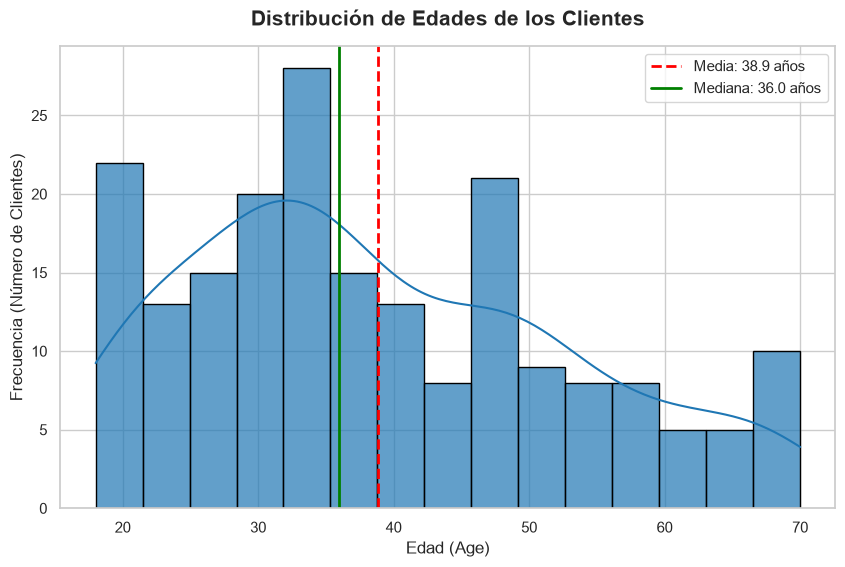

In [10]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

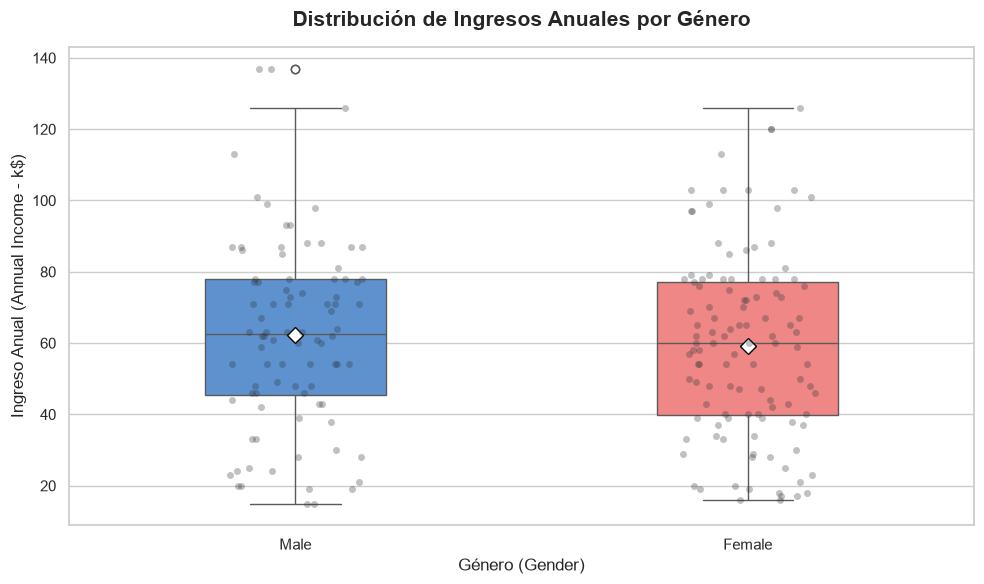

In [11]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

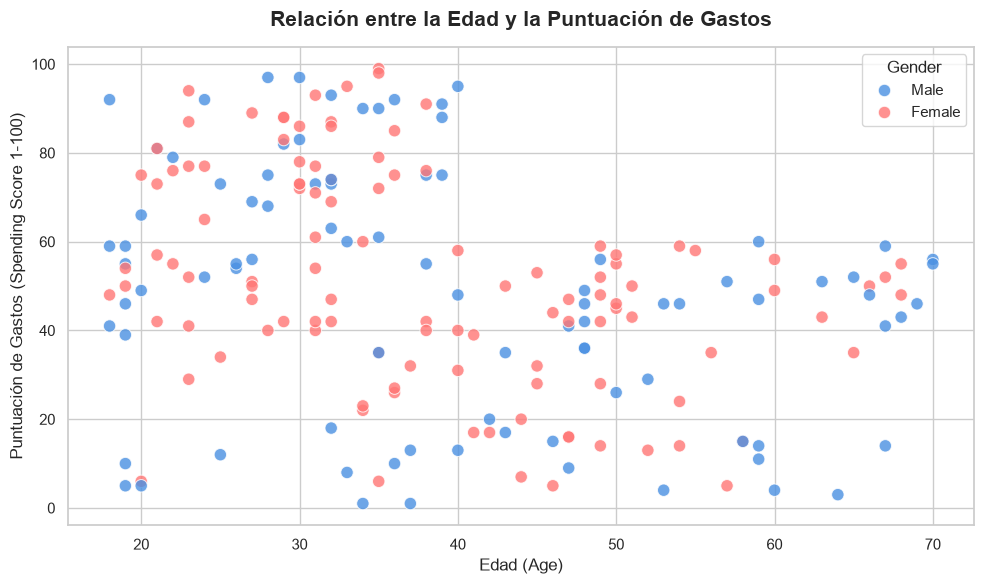

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.

# 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

Objetivo: Identificar si existe una relación lineal entre el ingreso y el gasto.

Respuesta esperada: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

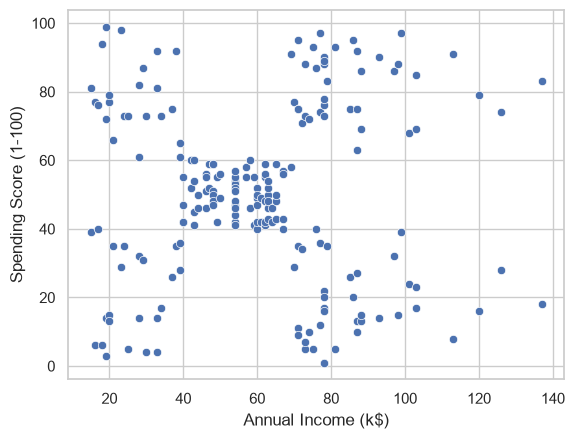

In [13]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

In [14]:
correlacion = df['Annual Income (k$)'].corr(
    df['Spending Score (1-100)']
)

print(correlacion)

0.009902848094037651


### **Análisis de los Resultados**

La correlación entre el ingreso anual y la puntuación de gasto es 0.0099, lo que indica una correlación lineal prácticamente nula entre ambas variables. Esto significa que, en este conjunto de datos, un mayor ingreso anual no se relaciona necesariamente con una mayor o menor puntuación de gasto. La distribución de los datos sugiere que el nivel de ingreso, por sí solo, no permite explicar de manera significativa el comportamiento del gasto de los clientes.

# 5.¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

Objetivo: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.

Respuesta esperada: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

<Axes: xlabel='Income Group', ylabel='Spending Score (1-100)'>

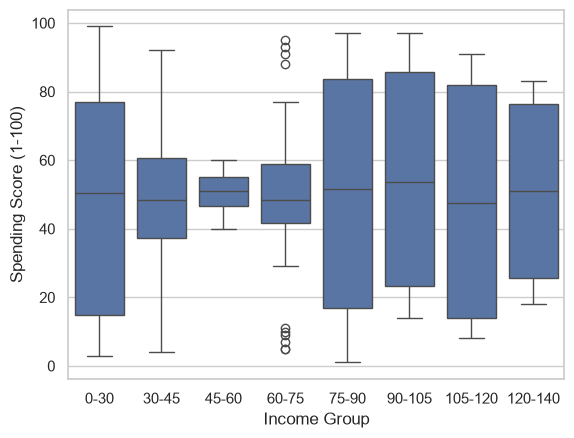

In [15]:
df['Income Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 30, 45, 60, 75, 90, 105, 120, 140],
    labels=['0-30', '30-45', '45-60', '60-75', '75-90', '90-105', '105-120', '120-140']
)
sns.boxplot(
    data=df,
    x='Income Group',
    y='Spending Score (1-100)'
)

In [16]:
df.groupby('Income Group')['Spending Score (1-100)'].describe()

,count,mean,std,min,25%,50%,75%,max
Income Group,,,,,,,,
0-30,32.0,49.656250,32.438139,3.0,14.75,50.5,77.00,99.0
30-45,26.0,49.730769,22.336621,4.0,37.25,48.5,60.75,92.0
45-60,40.0,50.500000,5.679473,40.0,46.75,51.0,55.00,60.0
60-75,44.0,49.590909,23.129884,5.0,41.75,48.5,59.00,95.0
75-90,36.0,50.333333,34.140885,1.0,16.75,51.5,83.75,97.0
90-105,14.0,53.357143,32.535441,14.0,23.25,53.5,85.75,97.0
105-120,4.0,48.500000,42.555846,8.0,14.00,47.5,82.00,91.0
120-140,4.0,50.750000,32.510255,18.0,25.50,51.0,76.25,83.0


### **Análisis de los Resultados**

Los diferentes rangos de ingreso presentan puntuaciones de gasto promedio muy similares, alrededor de 50. Sin embargo, algunos grupos muestran una mayor dispersión en sus puntuaciones, particularmente los rangos de 75–90 k$ y 90–105 k$. Por lo tanto, aunque existen clientes con puntuaciones de gasto muy altas en ciertos grupos, no se observa una diferencia clara en el nivel promedio de gasto asociada al ingreso anual.

# 6. ¿Cuál es la proporción de clientes por género?

Objetivo: Determinar el balance de género en el conjunto de datos.

Respuesta esperada: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

<Axes: xlabel='Gender', ylabel='count'>

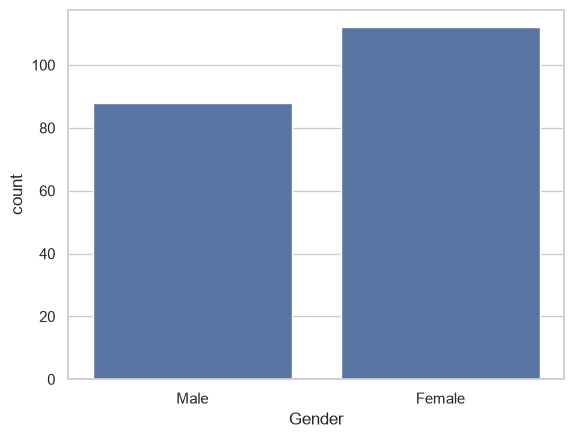

In [23]:
df['Gender'].value_counts(normalize = True)*100
sns.countplot(
    data=df,
    x='Gender'
)

### **Análisis de los Resultados**

La distribución por género muestra una mayor proporción de mujeres, representando aproximadamente el 56% de los clientes, mientras que los hombres representan el 44%. Esto indica que, aunque existe un ligero predominio de mujeres, la distribución entre ambos grupos es relativamente equilibrada.

# 7. ¿Qué grupos de edad gastan más en promedio?

Objetivo: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio. 

Respuesta esperada: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

In [25]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

df.groupby('Age Group')['Spending Score (1-100)'].mean()

Age Group
18-25    54.947368
26-35    64.450000
36-45    44.833333
46-55    36.702703
56+      38.379310
Name: Spending Score (1-100), dtype: float64

<Axes: xlabel='Age Group', ylabel='Spending Score (1-100)'>

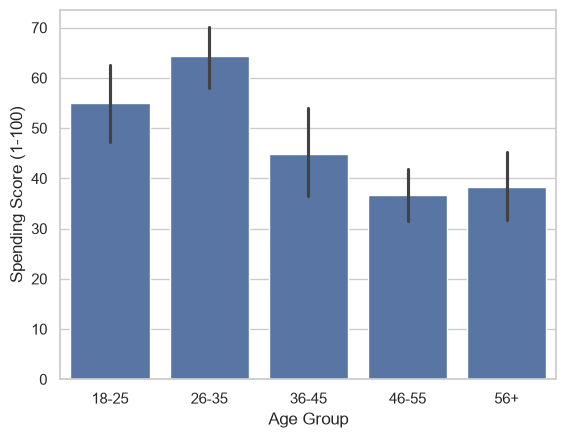

In [26]:
sns.barplot(
    data=df,
    x='Age Group',
    y='Spending Score (1-100)'
)

### **Análisis de los Resultados**

El grupo de edad de 26–35 años presenta la mayor puntuación de gasto promedio, con 64.45 puntos, seguido por el grupo de 18–25 años con 54.95. A partir de los 36 años se observa una disminución en la puntuación promedio de gasto, siendo el grupo de 46–55 años el que presenta el promedio más bajo, con 36.70 puntos. En este conjunto de datos, los clientes de 26–35 años muestran el mayor nivel promedio de gasto.

# 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

Objetivo: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.

Respuesta esperada: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

### **Análisis de los Resultados**



# 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?

Objetivo: Entender cómo se distribuyen estas dos variables en conjunto.

Respuesta esperada: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

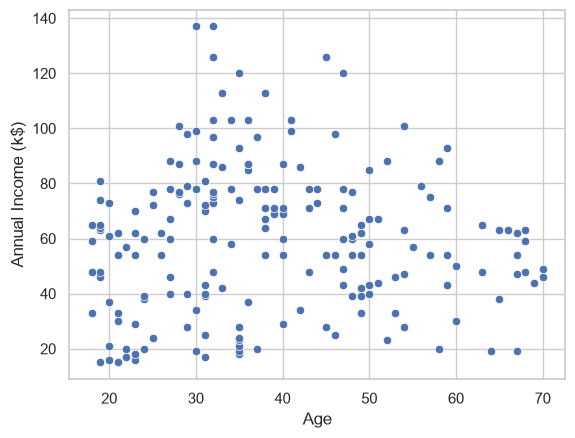

In [27]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)'
)

In [28]:
correlacion = df['Age'].corr(df['Annual Income (k$)'])

print(correlacion)

-0.012398042736060162


### **Análisis de los Resultados**

La correlación entre la edad y el ingreso anual es de -0.0124, lo que indica una relación lineal prácticamente nula entre ambas variables. Aunque se observa que algunos de los ingresos más altos corresponden a clientes de alrededor de 30 años, no existe una tendencia general que indique que la edad esté relacionada con un mayor o menor ingreso anual.

# 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

Objetivo: Analizar la relación entre la puntuación de gasto y el género.

Respuesta esperada: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

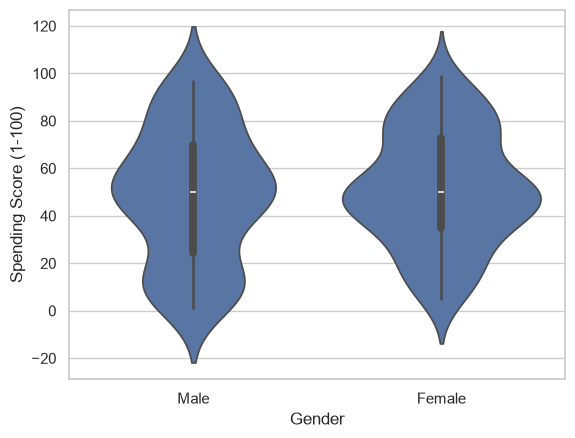

In [30]:
sns.violinplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)'
)

In [32]:
df.groupby('Gender')['Spending Score (1-100)'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,112.0,51.526786,24.11495,5.0,35.0,50.0,73.0,99.0
Male,88.0,48.511364,27.89677,1.0,24.5,50.0,70.0,97.0


### **Análisis de los Resultados**

La distribución de la puntuación de gasto es similar entre ambos géneros. Las mujeres presentan una puntuación promedio de 51.53, mientras que los hombres tienen un promedio de 48.51. Además, ambos grupos tienen una mediana de 50, lo que indica que el nivel central de gasto es prácticamente igual.En general, no se observa una diferencia marcada en la puntuación de gasto según el género.

## Inicio de la segmentación de clientes

Antes de aplicar K-Means debemos conocer exactamente qué contiene `df`. En principio, las variables más útiles para describir el comportamiento de compra son:

- `Age`: puede separar perfiles de clientes de distintas edades.
- `Annual Income (k$)`: representa la capacidad económica aproximada.
- `Spending Score (1-100)`: representa el comportamiento de gasto y suele ser especialmente útil para encontrar grupos.

`Gender` es categórica. No la usaremos automáticamente en K-Means porque convertirla en 0 y 1 haría que el algoritmo interpretara una distancia numérica entre categorías que no tiene un significado natural. Más adelante podremos comparar una versión que la incluya mediante una codificación adecuada.

No usaremos identificadores como `CustomerID`, si existen, porque solo identifican filas y no describen al cliente. Tampoco usaremos `Income Group`, porque fue creada a partir de `Annual Income (k$)` y repetiría esa información de forma discretizada.

Primero vamos a comprobar faltantes, duplicados, tipos de datos, rangos y categorías. Esta revisión puede confirmar o cambiar la selección anterior antes de preparar los datos.

In [33]:
print(f'Filas y columnas: {df.shape}')
print('\nColumnas:')
print(df.columns.tolist())

print('\nTipos de datos:')
print(df.dtypes)

print('\nValores faltantes por columna:')
print(df.isna().sum())

print(f'\nFilas duplicadas: {df.duplicated().sum()}')

print('\nResumen de variables numéricas:')
display(df.describe().T)

print('\nValores únicos de las variables categóricas:')
for columna in df.select_dtypes(include='object').columns:
    print(f'{columna}: {df[columna].unique()}')

Filas y columnas: (200, 7)

Columnas:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income Group', 'Age Group']

Tipos de datos:
CustomerID                   int64
Gender                         str
Age                          int64
Annual Income (k$)           int64
Spending Score (1-100)       int64
Income Group              category
Age Group                 category
dtype: object

Valores faltantes por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Income Group              0
Age Group                 0
dtype: int64

Filas duplicadas: 0

Resumen de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0



Valores únicos de las variables categóricas:
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [34]:
columna = 'Annual Income (k$)'

q1 = df[columna].quantile(0.25)
q3 = df[columna].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

clientes_atipicos = df[
    (df[columna] < limite_inferior) |
    (df[columna] > limite_superior)
]

print(clientes_atipicos)

     CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
198         199   Male   32                 137                      18   
199         200   Male   30                 137                      83   

    Income Group Age Group  
198      120-140     26-35  
199      120-140     26-35  


## Preparación de las variables para K-Means

Conservaremos los dos clientes con ingreso de `137 k$`: no son errores evidentes y tienen comportamientos de gasto distintos. Eliminarlos podría ocultar un segmento interesante.

Usaremos `Age`, `Annual Income (k$)` y `Spending Score (1-100)`. Dejaremos fuera `CustomerID`, `Gender`, `Income Group` y `Age Group` en esta primera versión.

K-Means agrupa observaciones calculando distancias. Por eso escalamos las variables con `StandardScaler`: cada variable queda centrada aproximadamente en 0 y con desviación estándar 1. Así, edad, ingreso y gasto participan de forma comparable, aunque originalmente estén en escalas distintas.

In [2]:
variables_segmentacion = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[variables_segmentacion].copy()

from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_escalada = escalador.fit_transform(X)

X_escalada_df = pd.DataFrame(
    X_escalada,
    columns=variables_segmentacion,
    index=df.index
)

display(X_escalada_df.head())
print('\nMedias después del escalado:')
print(X_escalada_df.mean().round(2))
print('\nDesviaciones estándar después del escalado:')
print(X_escalada_df.std().round(2))

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980



Medias después del escalado:
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Desviaciones estándar después del escalado:
Age                       1.0
Annual Income (k$)        1.0
Spending Score (1-100)    1.0
dtype: float64


## ¿Cuántos clusters debemos utilizar?

K-Means funciona así:

1. Elige `k` centros iniciales, llamados centroides.
2. Asigna cada cliente al centro más cercano.
3. Recalcula cada centro como el promedio de los clientes asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

El valor `k` indica cuántos segmentos queremos crear. No lo conocemos de antemano, por eso compararemos varios valores.

- **Método del codo:** mide la suma de distancias internas (`inertia`). Siempre disminuye al aumentar `k`; buscamos el punto donde la mejora comienza a ser mucho menor.
- **Silhouette Score:** mide si cada cliente está más cerca de su propio grupo que de los demás. Cuanto mayor sea, mejor separadas están las agrupaciones.

Estas métricas son ayudas para decidir, no una respuesta automática. También revisaremos si los grupos tienen sentido para Retail Max.

,k,Inercia,Silhouette Score
0,2,389.386,0.335
1,3,295.212,0.358
2,4,205.225,0.404
3,5,168.248,0.417
4,6,133.868,0.428
5,7,117.012,0.417
6,8,103.873,0.408
7,9,93.093,0.418
8,10,82.385,0.407


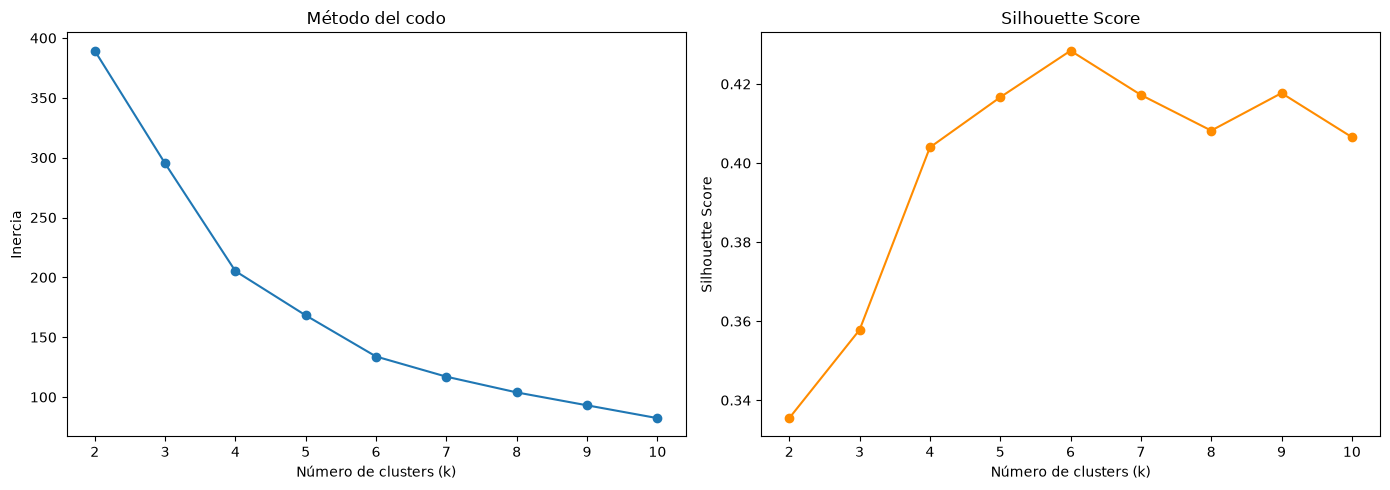

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

valores_k = range(2, 11)
inercia = []
silhouette = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_escalada)

    inercia.append(modelo.inertia_)
    silhouette.append(silhouette_score(X_escalada, etiquetas))

resultados_k = pd.DataFrame({
    'k': list(valores_k),
    'Inercia': inercia,
    'Silhouette Score': silhouette
})

display(resultados_k.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resultados_k['k'], resultados_k['Inercia'], marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(valores_k))

axes[1].plot(resultados_k['k'], resultados_k['Silhouette Score'], marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(valores_k))

plt.tight_layout()
plt.show()

## Elección inicial: 6 clusters

El valor elegido inicialmente es `k = 6` porque:

- Tiene el mayor Silhouette Score de los valores probados: aproximadamente `0.428`.
- En el gráfico del codo, la reducción de la inercia empieza a ser más moderada después de 6.
- Seis grupos permiten distinguir perfiles de edad, ingreso y gasto sin crear demasiados segmentos pequeños.

Esta es una elección inicial. Después revisaremos el tamaño y las características de cada grupo para comprobar si tiene sentido para el negocio.

In [4]:
k_elegido = 6

modelo_kmeans = KMeans(
    n_clusters=k_elegido,
    random_state=42,
    n_init=10
)

etiquetas = modelo_kmeans.fit_predict(X_escalada)
df['Cluster'] = etiquetas

print('Clientes asignados a cada cluster:')
print(df['Cluster'].value_counts().sort_index())

display(df[variables_segmentacion + ['Cluster']].head())

Clientes asignados a cada cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,5
3,23,16,77,4
4,31,17,40,5


## Visualización de los clusters

Los números de cluster (`0`, `1`, etc.) son etiquetas técnicas y no significan que un grupo sea mejor que otro. Para observar la separación, representaremos el ingreso anual frente a la puntuación de gasto y colorearemos cada cliente según su cluster.

La edad no aparece en este gráfico, por lo que después necesitaremos una tabla resumen que incluya las tres variables.

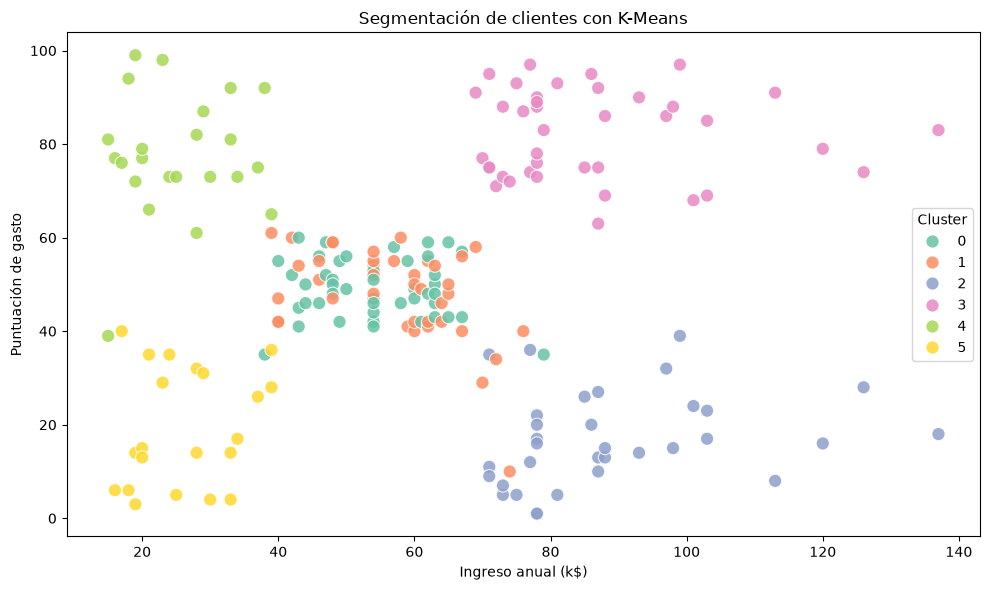

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=90,
    alpha=0.85
)

plt.title('Segmentación de clientes con K-Means')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Puntuación de gasto')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## Perfil de cada segmento

Para interpretar los clusters calcularemos, para cada grupo, el número de clientes y el promedio de edad, ingreso y puntuación de gasto. Los nombres comerciales se decidirán después de observar esta tabla.

In [6]:
resumen_clusters = df.groupby('Cluster')[variables_segmentacion].mean().round(2)
resumen_clusters.insert(0, 'Clientes', df['Cluster'].value_counts().sort_index())

resumen_clusters

,Clientes,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


## Género como variable descriptiva

`Gender` no se utilizó para formar los clusters porque es categórica, pero podemos observar su distribución dentro de cada segmento. Esto ayuda a describirlos sin hacer que el género determine la agrupación.

In [7]:
distribucion_genero = pd.crosstab(
    df['Cluster'],
    df['Gender'],
    normalize='index'
).mul(100).round(1)

distribucion_genero

Gender,Female,Male
Cluster,,
0,57.8,42.2
1,64.1,35.9
2,42.4,57.6
3,53.8,46.2
4,56.5,43.5
5,61.9,38.1


## Descripción de los segmentos

A partir de los promedios observados, podemos describir los grupos sin interpretar sus números como jerarquías:

| Cluster | Descripción | Evidencia principal |
| --- | --- | --- |
| 0 | Clientes mayores de ingreso medio y gasto medio | Edad media 56.3, ingreso 54.3 k$ y gasto 49.1 |
| 1 | Clientes jóvenes de ingreso medio y gasto medio | Edad media 26.8, ingreso 57.1 k$ y gasto 48.1 |
| 2 | Clientes de ingreso alto y gasto bajo | Ingreso medio 88.9 k$ y gasto 17.0 |
| 3 | Clientes de ingreso alto y gasto alto | Ingreso medio 86.5 k$ y gasto 82.1 |
| 4 | Clientes de ingreso bajo y gasto alto | Ingreso medio 25.3 k$ y gasto 77.6 |
| 5 | Clientes de ingreso bajo y gasto bajo | Ingreso medio 26.3 k$ y gasto 19.4 |

Estas etiquetas son descriptivas, no verdades absolutas: representan promedios y no necesariamente describen a cada cliente individual.

In [8]:
nombres_clusters = {
    0: 'Mayores de ingreso medio y gasto medio',
    1: 'Jóvenes de ingreso medio y gasto medio',
    2: 'Ingreso alto y gasto bajo',
    3: 'Ingreso alto y gasto alto',
    4: 'Ingreso bajo y gasto alto',
    5: 'Ingreso bajo y gasto bajo'
}

df['Segmento'] = df['Cluster'].map(nombres_clusters)

resumen_segmentos = resumen_clusters.copy()
resumen_segmentos.insert(0, 'Segmento', resumen_segmentos.index.map(nombres_clusters))
resumen_segmentos

,Segmento,Clientes,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,Mayores de ingreso medio y gasto medio,45,56.33,54.27,49.07
1,Jóvenes de ingreso medio y gasto medio,39,26.79,57.10,48.13
2,Ingreso alto y gasto bajo,33,41.94,88.94,16.97
3,Ingreso alto y gasto alto,39,32.69,86.54,82.13
4,Ingreso bajo y gasto alto,23,25.00,25.26,77.61
5,Ingreso bajo y gasto bajo,21,45.52,26.29,19.38


## Posibles acciones para Retail Max

- **Mayores de ingreso medio y gasto medio:** clientes relativamente mayores con comportamiento estable. Se podrían ofrecer productos de reposición, beneficios de fidelidad y promociones sencillas que incentiven compras recurrentes.
- **Jóvenes de ingreso medio y gasto medio:** grupo joven con margen para aumentar su frecuencia de compra. Pueden funcionar campañas digitales, recomendaciones personalizadas y promociones por categorías.
- **Ingreso alto y gasto bajo:** tienen capacidad económica, pero actualmente gastan poco. Conviene probar mensajes de valor, productos premium, atención personalizada o incentivos de primera compra, sin asumir que todos responderán igual.
- **Ingreso alto y gasto alto:** es un grupo prioritario por su alto valor potencial. Se pueden ofrecer servicios premium, acceso anticipado, beneficios exclusivos y programas de fidelización.
- **Ingreso bajo y gasto alto:** muestran una fuerte disposición a gastar pese a su ingreso medio bajo. Pueden responder a promociones, paquetes, financiación o recompensas por frecuencia, cuidando que las ofertas sean sostenibles.
- **Ingreso bajo y gasto bajo:** requieren una estrategia de activación de bajo costo. Se pueden probar descuentos selectivos, productos de entrada y comunicaciones que ayuden a descubrir la propuesta de valor.

El género puede utilizarse para describir la composición de cada segmento, pero en este conjunto no presenta diferencias suficientemente fuertes como para construir una estrategia basada únicamente en esa variable.

## Conclusión

El clustering permitió encontrar seis perfiles de clientes sin utilizar etiquetas previas. La segmentación se construyó con edad, ingreso anual y puntuación de gasto, después de revisar la calidad de los datos y escalar las variables para que fueran comparables.

El valor `k = 6` fue una elección razonable porque obtuvo el mejor Silhouette Score entre los valores probados y mostró una estructura interpretable en el método del codo. Los segmentos más diferenciados fueron los de ingreso alto con gasto bajo o alto, y los de ingreso bajo con gasto bajo o alto.

Estos grupos pueden ayudar a Retail Max a diseñar campañas más específicas que una promoción general para todos los clientes. Sin embargo, deben considerarse una primera segmentación exploratoria: sería recomendable validarla con datos reales de compras, frecuencia, categorías adquiridas y respuesta a campañas. También conviene volver a entrenar y revisar los clusters periódicamente, porque el comportamiento de los clientes puede cambiar.